Tarefas 
- entender porque o shap do tradicional gbr nao esta compativel com o artigo. sera que foi usado set de treino? 
- terminar de importar os codigos de injecao de ruidos e analises morfologicas
- Consolidar todas as "observacao" para melhor entendimento
- Em relação ao Shap values entender as diferencas nos tipos de graficos



# 0. Imports and global configuration


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import cross_val_predict, KFold, train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Data loading and description 

## Read data

In [3]:
# Load Dataset (replace 'file_path' with your file location in Colab)
file_path = './content/dados_jamovi.xlsx'  # Upload your dataset to Colab
data = pd.read_excel(file_path)


## Data Description

In [4]:
data.head()

,Dmax (mean) [µm],Dmed (mean) [µm],Dmin (mean) [µm],Area (mean) [µm²],Velocity (mean) [µm/s],Distance (sum) [µm],Rel.Time (num) [s],Area (polygon) (mean) [µm²],Area/Box (mean) [µm²],Axis (major) (mean) [µm],...,Perim. (convex) (mean) [µm],Perim. (ellipse) (mean) [µm],Perim. (ratio) (mean) [µm],Perimeter2 (mean) [µm],Perimeter3 (mean) [µm],Radius (max) (mean) [µm],Radius (min) (mean) [µm],Roundness (mean),Size (length) (mean) [µm],Size (width) (mean) [µm]
0,2278.275745,1551.198298,711.606809,1.612164e+06,1399.779783,6438.99,47,1466525.53,0.46,2284.51,...,5746.35,5338.09,0.82,7615.24,7006.98,1329.19,267.71,2.67,2360.02,1219.27
1,3442.800833,2611.194583,1959.983750,5.709536e+06,2415.071739,5554.67,24,5488243.60,0.73,3343.78,...,9110.69,8811.35,0.90,10708.58,10125.68,1770.54,859.83,1.49,3405.16,2470.43
2,2372.206296,1943.840370,1434.028889,3.149271e+06,2265.156923,5889.41,27,2978574.57,0.61,2279.25,...,7027.62,6492.88,0.81,9172.29,8647.90,1434.45,511.19,2.01,2495.45,2040.84
3,1921.425405,1496.906486,1080.961892,1.835665e+06,1804.333056,6495.60,37,1711958.32,0.63,1838.61,...,5162.67,4959.59,0.84,6476.37,6131.23,1031.68,466.54,1.75,1889.67,1450.77
4,1987.391429,1533.741429,934.360000,1.807783e+06,1861.068333,1116.64,7,1682195.05,0.59,2114.39,...,5396.27,5191.92,0.90,6369.07,5980.95,1079.78,418.74,1.69,2009.11,1196.00


In [5]:
data.columns # acrescentar a descricao das colunas e definir a variavel target

Index(['Dmax (mean) [µm]', 'Dmed (mean) [µm]', 'Dmin (mean) [µm]',
       'Area (mean) [µm²]', 'Velocity (mean) [µm/s]', 'Distance (sum) [µm]',
       'Rel.Time (num) [s]', 'Area (polygon) (mean) [µm²]',
       'Area/Box (mean) [µm²]', 'Axis (major) (mean) [µm]',
       'Axis (minor) (mean) [µm]', 'Box Height (mean) [µm]',
       'Box Width (mean) [µm]', 'Box X/Y (mean) [µm]', 'Clumpiness (mean)',
       'Cluster (mean)', 'Count (adjusted) (mean)',
       'Den./Inten. (std.dev.) (mean)', 'Den./Inten. (mean)',
       'Feret (max) (mean)', 'Feret (mean) (mean)', 'Feret (min) (mean)',
       'Fractal Dim. (mean)', 'Heterogeneity (mean)', 'Hole Area (mean) [µm²]',
       'Hole Ratio (mean)', 'Holes (mean)', 'Margination (mean)',
       'Perim. (convex) (mean) [µm]', 'Perim. (ellipse) (mean) [µm]',
       'Perim. (ratio) (mean) [µm]', 'Perimeter2 (mean) [µm]',
       'Perimeter3 (mean) [µm]', 'Radius (max) (mean) [µm]',
       'Radius (min) (mean) [µm]', 'Roundness (mean)',
       'Size (le

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 38 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Dmax (mean) [µm]               916 non-null    float64
 1   Dmed (mean) [µm]               916 non-null    float64
 2   Dmin (mean) [µm]               883 non-null    float64
 3   Area (mean) [µm²]              916 non-null    float64
 4   Velocity (mean) [µm/s]         916 non-null    float64
 5   Distance (sum) [µm]            916 non-null    float64
 6   Rel.Time (num) [s]             916 non-null    int64  
 7   Area (polygon) (mean) [µm²]    916 non-null    float64
 8   Area/Box (mean) [µm²]          916 non-null    float64
 9   Axis (major) (mean) [µm]       916 non-null    float64
 10  Axis (minor) (mean) [µm]       916 non-null    float64
 11  Box Height (mean) [µm]         916 non-null    float64
 12  Box Width (mean) [µm]          916 non-null    flo

In [7]:
data.select_dtypes(include=[np.number]).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 38 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Dmax (mean) [µm]               916 non-null    float64
 1   Dmed (mean) [µm]               916 non-null    float64
 2   Dmin (mean) [µm]               883 non-null    float64
 3   Area (mean) [µm²]              916 non-null    float64
 4   Velocity (mean) [µm/s]         916 non-null    float64
 5   Distance (sum) [µm]            916 non-null    float64
 6   Rel.Time (num) [s]             916 non-null    int64  
 7   Area (polygon) (mean) [µm²]    916 non-null    float64
 8   Area/Box (mean) [µm²]          916 non-null    float64
 9   Axis (major) (mean) [µm]       916 non-null    float64
 10  Axis (minor) (mean) [µm]       916 non-null    float64
 11  Box Height (mean) [µm]         916 non-null    float64
 12  Box Width (mean) [µm]          916 non-null    flo

# 2. Declare predictors and target variable

In [8]:
target_column = 'Velocity (mean) [µm/s]'
features_columns = [col for col in data.columns if col != target_column]

In [9]:
X = data[features_columns]
y = data[target_column]

In [10]:
# Limpeza e remocao de Nan
mask = X.notna().all(axis=1) & y.notna()

X = X.loc[mask]
y = y.loc[mask]


# 3. Split train and test set

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state = 42 
)

# 3. Modeling Experiments

##### Observacao 

- foi introduzido um hiperparametro (max_depth) no treinamento do modelo

## Experiment A - Traditional Gradient Boosting Regressor 


### Train and predict

In [12]:

# Define the Gradient Boosting Regressor
traditional_gbr_model = GradientBoostingRegressor(
    n_estimators=200, 
    learning_rate=0.05, 
    max_depth= 3, # esse hiperparametro nao aparecia no paper original 
    random_state=42
    )


In [13]:
# Fit the model
traditional_gbr_model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [14]:
# Make prediction
y_pred = traditional_gbr_model.predict(X_test)

### Calculate residuals 

In [15]:
trad_gbr_residuals = y_test - y_pred

### Save results for evaluation analysis

In [16]:
df_eval_a = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred,
    "residuals": trad_gbr_residuals,
    "experiment": "Tradicional GBR"
})


## Experiment B - Physics-based feature engineering Gradient Boosting Regressor (PFE - GBR)


- **Reynolds number (Re):** captures flow regime effects
- **Drag coefficient (Cd):** accounts for non-linear drag behavior
- **Drag force (Fd):** expresses momentum exchange

A characteristic velocity is used in the computation of these quantities and is obtained from experimental measurements.

### Feature Engineering

#### Phisical features

##### Observacao
- No codigo original, para o calculo de Re é utilizado o raio, enquanto aqui foi utilizado o diametro equivalente por área projetada
- Esta havendo leakage de informacao: isso porque para o calculo de Reynolds utiliza-se a velocidade caracteristica que é a resposta que o sistema procura
    - Utilizar pipeline nao resolverá: a velocidade caracteristica ainda será vazada para dentro do modelo 
    - Propostas:
        - testar a efetividade do modelo sem a utilização de Reynolds como variavel preditora
        - testar a utilização de Stokes como substituto para "velocidade caracteristica" - assim nao haverá leakage

In [17]:
# Copy data
# Ja trago apenas as entradas apos a limpeza dos nulos
data_run2 = data.loc[X.index].copy()

In [18]:
# Versao 2 da Feature Engineering
# Principal diferença dessa versao da feature engineering é a utilizacao do d (em lugar do 'Radius (max) (mean) [µm]') para o calculo de Re

rho_f = 1000.0
mu = 0.001
g = 9.81  # Gravitational acceleration (m/s²)
rho_p = 2600  # Particle density (kg/m³)

A = data_run2["Area (mean) [µm²]"] * 1e-12      # área projetada (m²)
r = data_run2["Radius (max) (mean) [µm]"] * 1e-6    # raio maximo (m)
v = data_run2[target_column] * 1e-6        # velocidade medida (m/s)

d = 2.0 * np.sqrt(A / np.pi) # # Diâmetro equivalente por área projetada: d = 2*sqrt(A/pi)
Re = (rho_f * v * d) / mu # no codigo original em vez de "d" usamos simplesmente o raio 
Re = Re.replace([np.inf, -np.inf], np.nan)
Re = Re.where(Re > 0, np.nan)

# Re = (
#     Re
#     .where(Re > 0) # remove valores não físicos
#     .replace([np.inf, -np.inf], np.nan) # remove infinitos
# )
# “Non-physical Reynolds number values (Re ≤ 0) and infinite values arising from numerical instabilities were discarded and treated as missing data prior to model training.”
# Re = 0 representa velocidade nula o que nao importa no processo
# Re < 0 nao faz sentido, dado que velocidade e as outras variaveis nunca serao menor que 0

Cd = 24.0 / Re
Fd = 0.5 * rho_f * Cd * A * (v ** 2)
r2 = r ** 2
Stokes = (2 / 9) * ((rho_p - rho_f) * g * r2 / mu)

data_run2["PFE_Re"] = Re
data_run2["PFE_Cd"] = Cd
data_run2["PFE_Fd"] = Fd
data_run2["PFE_r2"] = r2


# physics_features = ['PFE_r2', 'PFE_Re', 'PFE_Cd', 'PFE_Fd']
physics_features = ['PFE_Re', 'PFE_Cd',  'PFE_Fd', 'PFE_r2']


In [19]:
X_train_pfe = pd.concat([X_train, data_run2.loc[X_train.index,physics_features]], axis=1)
X_test_pfe = pd.concat([X_test, data_run2.loc[X_test.index,physics_features]], axis=1)

In [20]:

# # Impute Missing Values
# imputer = SimpleImputer(strategy='mean')
# X_pfe_imputed = imputer.fit_transform(X_pfe)


### Training model

In [21]:

# Define the Gradient Boosting Regressor
pfe_gbr_model = GradientBoostingRegressor(
    n_estimators=200, 
    learning_rate=0.05, 
    max_depth = 3,
    random_state=42
    )


In [22]:
# Fit the model
pfe_gbr_model.fit(X_train_pfe, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [23]:
# Make prediction
y_pred_pfe = pfe_gbr_model.predict(X_test_pfe)

### Calculate residuals 

In [24]:
pfe_gbr_residuals = y_test - y_pred_pfe

### Save results for evaluation analysis

In [25]:
df_eval_b = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred_pfe,
    "residuals": pfe_gbr_residuals, 
    "experiment": "PFE - GBR"
})

In [26]:
df_eval_b

,y_true,y_pred,residuals,experiment
44,1597.297778,1665.491416,-68.193638,PFE - GBR
839,3157.878723,3506.518008,-348.639285,PFE - GBR
720,3142.272973,2625.623288,516.649685,PFE - GBR
660,4202.691304,4484.488257,-281.796953,PFE - GBR
911,2872.106122,2803.993958,68.112164,PFE - GBR
...,...,...,...,...
118,1377.862500,1481.600048,-103.737548,PFE - GBR
388,1034.317821,986.201984,48.115837,PFE - GBR
494,2086.659302,2013.451565,73.207737,PFE - GBR
29,1489.795435,1498.740287,-8.944852,PFE - GBR


# 4. Holdout Evaluation and Error Interpretation

In [27]:
df_evaluation_analysis = pd.concat(
    [df_eval_a, df_eval_b],
    axis=0
)

In [28]:
# criar resíduos
# df_evaluation_analysis["residual"] = df_evaluation_analysis["y_true"] - df_evaluation_analysis["y_pred"]

# separar experimentos
df_evaluation_analysis_trad = df_evaluation_analysis[df_evaluation_analysis["experiment"] == "Tradicional GBR"]
df_evaluation_analysis_pfe  = df_evaluation_analysis[df_evaluation_analysis["experiment"] == "PFE - GBR"]

## Real vs Predicted Velocity


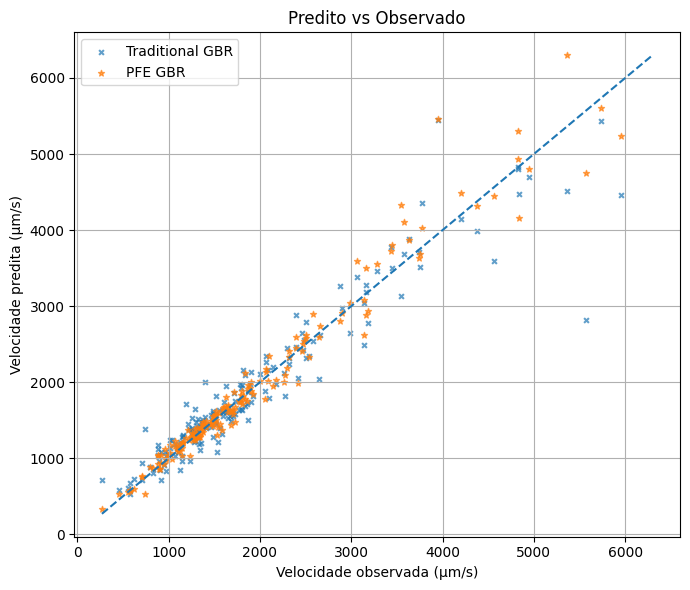

In [29]:
plt.figure(figsize=(7, 6))

# scatter tradicional
plt.scatter(
    df_evaluation_analysis_trad["y_true"],
    df_evaluation_analysis_trad["y_pred"],
    marker="x",
    alpha=0.7,
    s=12,
    label="Traditional GBR"
)

# scatter PFE
plt.scatter(
    df_evaluation_analysis_pfe["y_true"],
    df_evaluation_analysis_pfe["y_pred"],
    marker="*",
    alpha=0.7,
    s=20,
    label="PFE GBR"
)

# linha identidade
min_val = min(df_evaluation_analysis["y_true"].min(), df_evaluation_analysis["y_pred"].min())
max_val = max(df_evaluation_analysis["y_true"].max(), df_evaluation_analysis["y_pred"].max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Velocidade observada (µm/s)")
plt.ylabel("Velocidade predita (µm/s)")
plt.title("Predito vs Observado")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [30]:
max_val

np.float64(6298.671811793509)

##### Observacao 

1. O grafico de predito x real do artigo usa o set de treino para plotar os graficos, gerando resultados diferentes do que o codigo traz


## Error Analysis

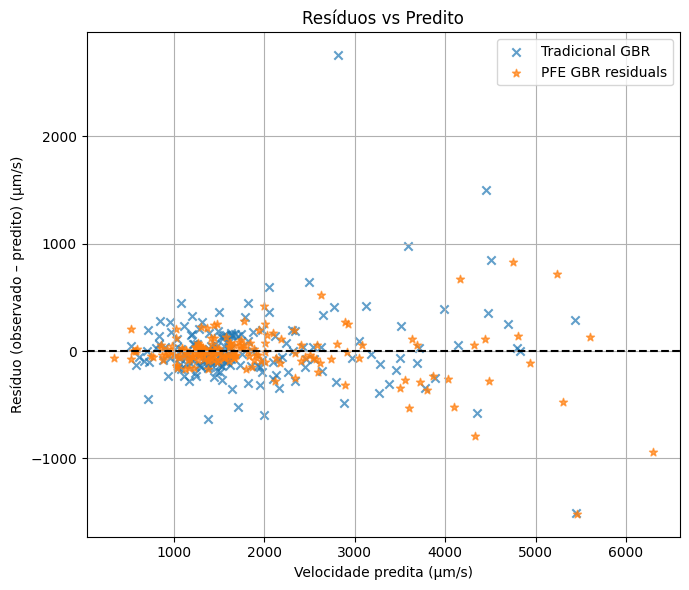

In [31]:
plt.figure(figsize=(7, 6))

# residuos Tradicional GRB
plt.scatter(
    df_evaluation_analysis_trad['y_pred'], 
    df_evaluation_analysis_trad['residuals'], 
    marker="x", 
    alpha=0.7,
    label = "Tradicional GBR"
)

# resíduos PFE
plt.scatter(
    df_evaluation_analysis_pfe['y_pred'], 
    df_evaluation_analysis_pfe['residuals'], 
    marker="*",
    alpha=0.7,
    label="PFE GBR residuals"
)

# linha zero
plt.axhline(
    0,
    linestyle="--",
    color="black"
)

plt.xlabel("Velocidade predita (µm/s)")
plt.ylabel("Resíduo (observado – predito) (µm/s)")
plt.title("Resíduos vs Predito")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

##### Observacao

1. Enquanto Tradicional GBR prediz valores até +- 5300, o PFE faz predições que ultrapassam 6000, e justamente essas possuem os maiores residuos do sistema. Por que sera que o PFE extrapola em tanto? 
2. Vale plotar um grafico em que o eixo x são os valores reais? Assim, ficaria mais facil de entender em que intervalo em relação aos valores reais fica mais acurada a predicao
3. o codigo passado pelo professor nao produz o mesmo grafico do artigo. Provavel por conta de versoes diferentes dos pacotes utilizados

# 5. Model Interpretability - SHAP Values

##### Observacao 

Mesmo o codigo do professor apresenta resultados de shap diferentes do artigo. as tendencias sao similares, mas nao da pra falar que sao a mesma coisa

## shap.TreeExplainer

### Tradicional GBR

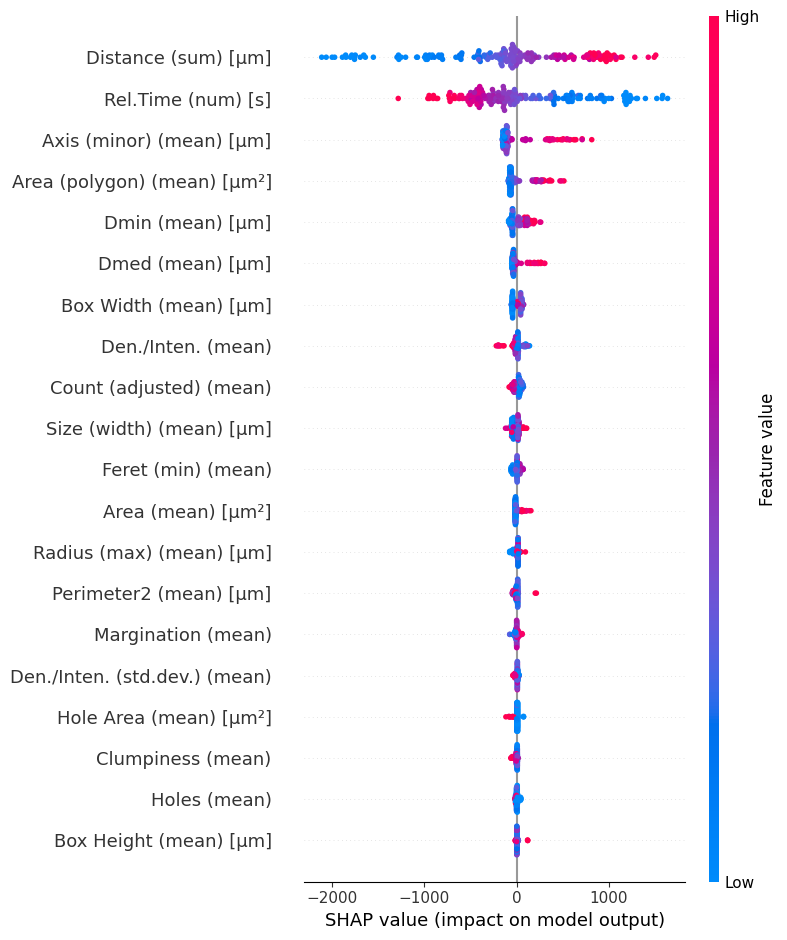

In [32]:
# Essa implementacao nao esta de acordo com o codigo. Mas é curioso entender o porque os valores se distanciaram tanto do apresentado no artigo com TreeExplainer
explainer = shap.TreeExplainer(traditional_gbr_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)


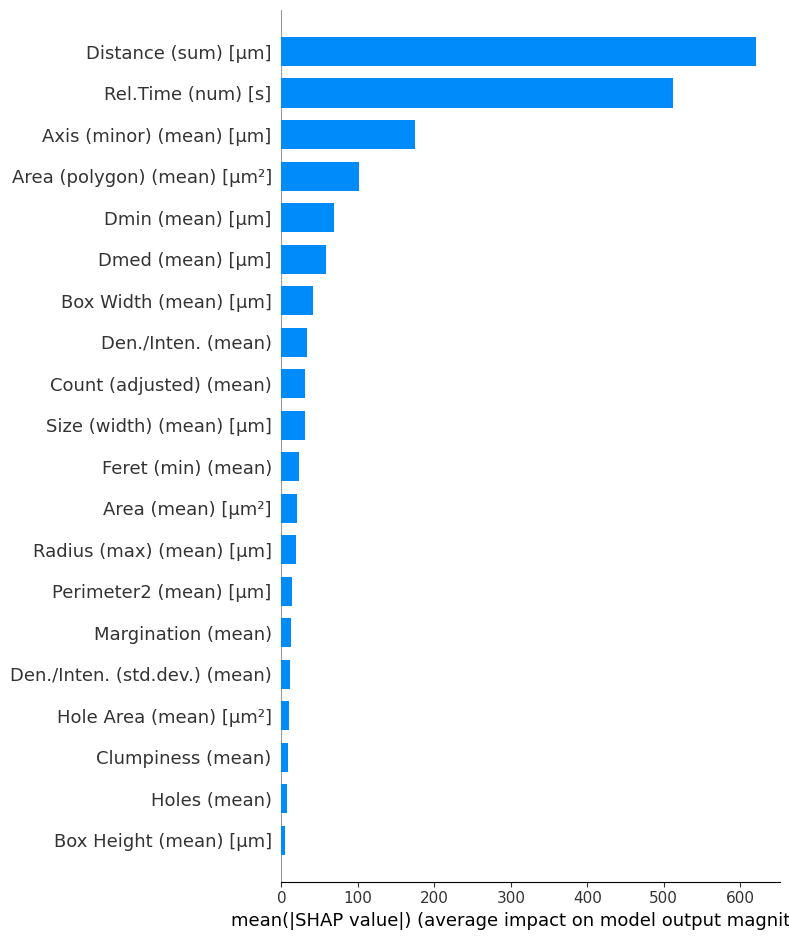

In [33]:
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()

### PFE - GBR

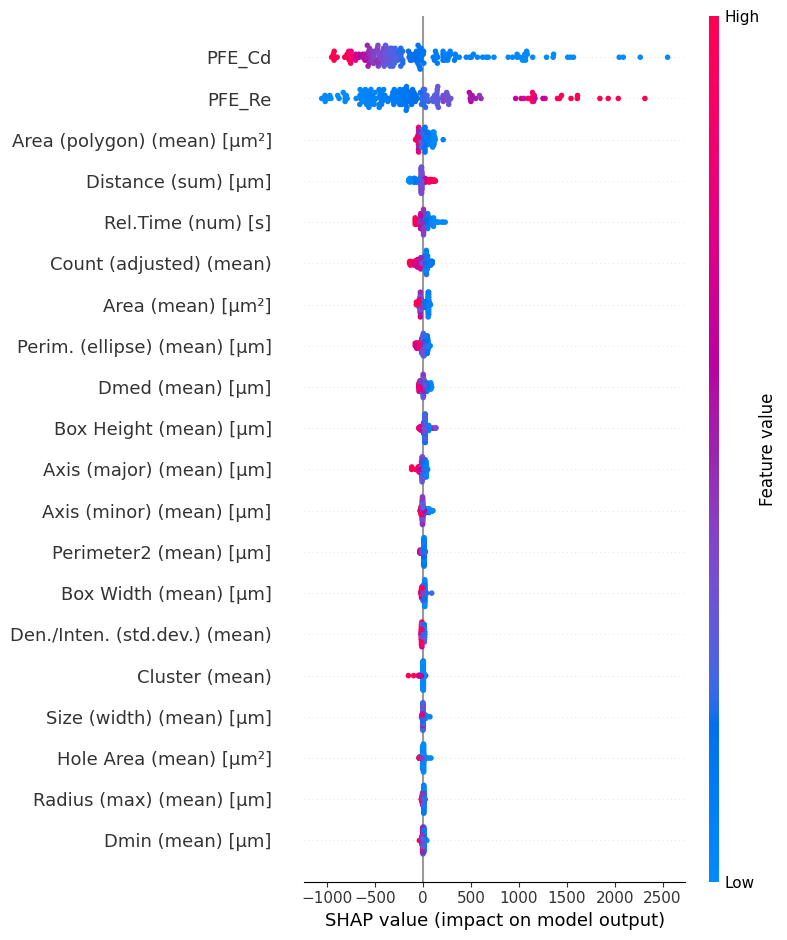

In [34]:
# PFE - GBR
explainer = shap.TreeExplainer(pfe_gbr_model)
shap_values_pfe = explainer.shap_values(X_test_pfe)

shap.summary_plot(shap_values_pfe, X_test_pfe, show=False)


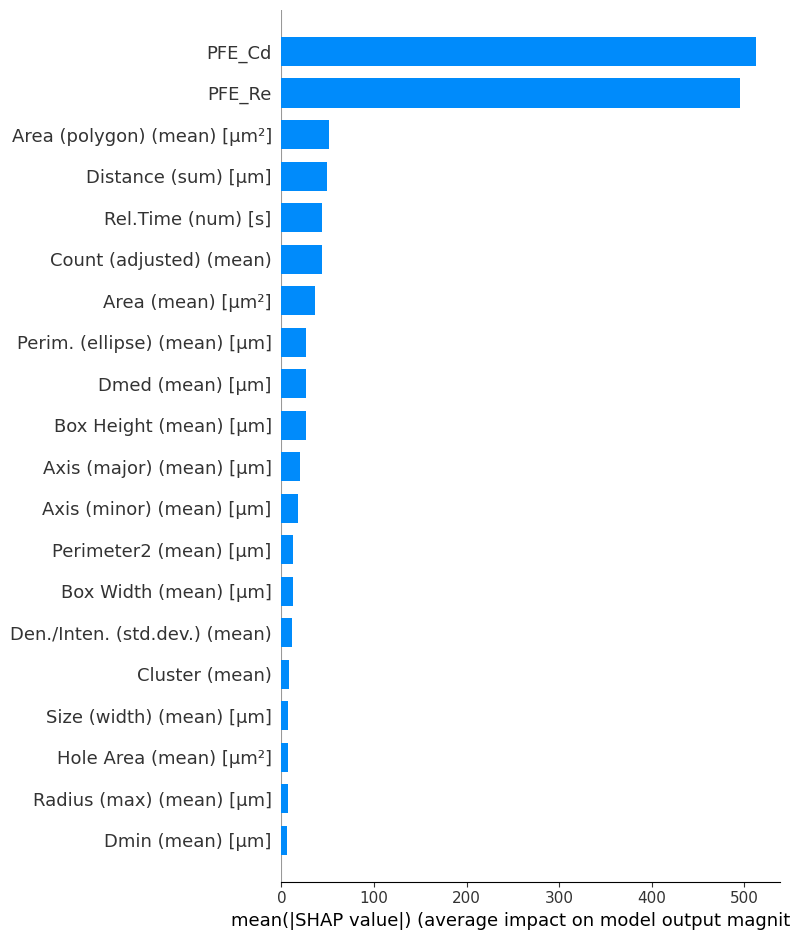

In [35]:
shap.summary_plot(shap_values_pfe, X_test_pfe, plot_type="bar", show=False)
plt.tight_layout()

In [36]:
X_test_pfe

,Dmax (mean) [µm],Dmed (mean) [µm],Dmin (mean) [µm],Area (mean) [µm²],Distance (sum) [µm],Rel.Time (num) [s],Area (polygon) (mean) [µm²],Area/Box (mean) [µm²],Axis (major) (mean) [µm],Axis (minor) (mean) [µm],...,Perimeter3 (mean) [µm],Radius (max) (mean) [µm],Radius (min) (mean) [µm],Roundness (mean),Size (length) (mean) [µm],Size (width) (mean) [µm],PFE_Re,PFE_Cd,PFE_Fd,PFE_r2
44,3444.190541,2277.320811,1125.498378,4.138137e+06,5750.27,37,3931818.18,0.51,3476.62,1600.56,...,10282.45,1841.48,457.98,2.14,3479.40,1811.72,3.666430,6.545877,3.455529e-08,3.391049e-06
839,3264.133333,2455.050833,1511.090625,4.920702e+06,14842.03,48,4716784.23,0.60,3356.21,1901.52,...,9284.25,1689.08,705.04,1.46,3269.04,2040.94,7.904311,3.036318,7.449638e-08,2.852991e-06
720,3259.284444,2263.453056,1591.890833,4.428158e+06,11626.41,36,4206048.53,0.47,3273.00,1887.70,...,11075.20,2016.91,653.87,2.35,3452.42,2214.11,7.461232,3.216627,7.032045e-08,4.067926e-06
660,6518.812727,3945.879091,1748.776818,1.418670e+07,9666.19,22,13859850.14,0.54,6256.70,3117.64,...,22755.11,3317.88,530.06,2.98,6412.89,3786.57,17.861717,1.343656,1.683427e-07,1.100833e-05
911,3136.153200,2408.649600,1890.947000,4.812445e+06,14073.32,50,4617799.53,0.63,2953.81,2111.67,...,8880.15,1652.12,837.00,1.36,2990.50,2219.97,7.109490,3.375770,6.700536e-08,2.729500e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,2196.584444,1691.822000,1178.224222,2.339429e+06,6062.59,45,2190514.67,0.57,2072.34,1515.51,...,7146.17,1182.32,516.11,1.86,2212.74,1722.92,2.378022,10.092421,2.241233e-08,1.397881e-06
388,2399.513291,1656.218734,886.718481,2.150727e+06,8067.68,79,1982261.81,0.55,2414.12,1222.72,...,8303.01,1323.37,312.05,2.79,2482.32,1474.79,1.711598,14.021985,1.613143e-08,1.751308e-06
494,1862.538471,1496.201882,1154.030235,1.799565e+06,17945.27,85,1685307.91,0.70,1791.94,1288.10,...,5184.63,956.03,531.13,1.27,1892.98,1335.07,3.158569,7.598378,2.976881e-08,9.139934e-07
29,1923.386596,1324.641915,1014.149362,1.405056e+06,6853.06,47,1298697.04,0.63,1789.62,1021.89,...,4969.56,1027.15,464.43,1.51,1963.62,1099.78,1.992639,12.044330,1.878018e-08,1.055037e-06


## shap.Explainer

### Tradicional GBR

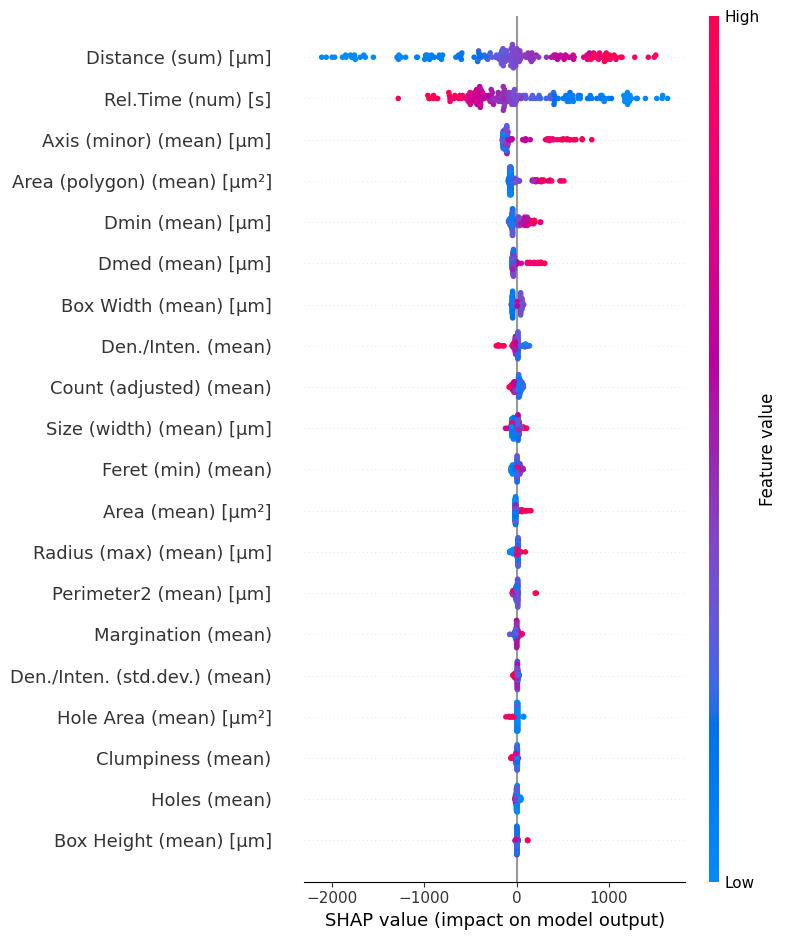

In [37]:
# Essa implementacao nao esta de acordo com o codigo. Mas é curioso entender o porque os valores se distanciaram tanto do apresentado no artigo com TreeExplainer
explainer = shap.Explainer(traditional_gbr_model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)


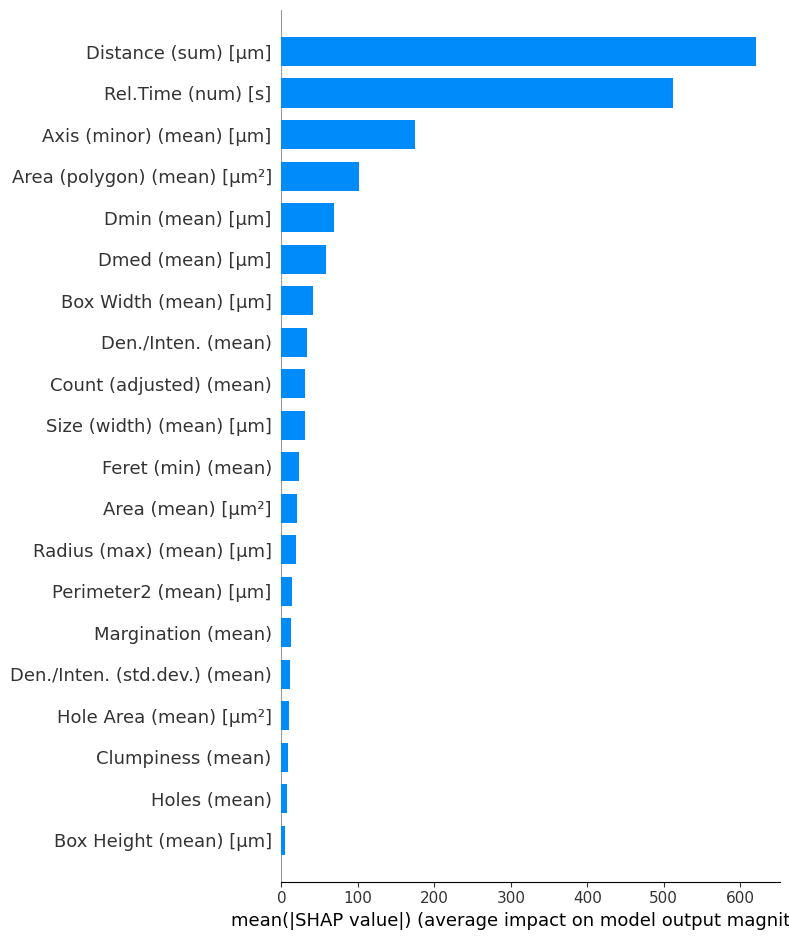

In [38]:
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()

### PFE - GBR

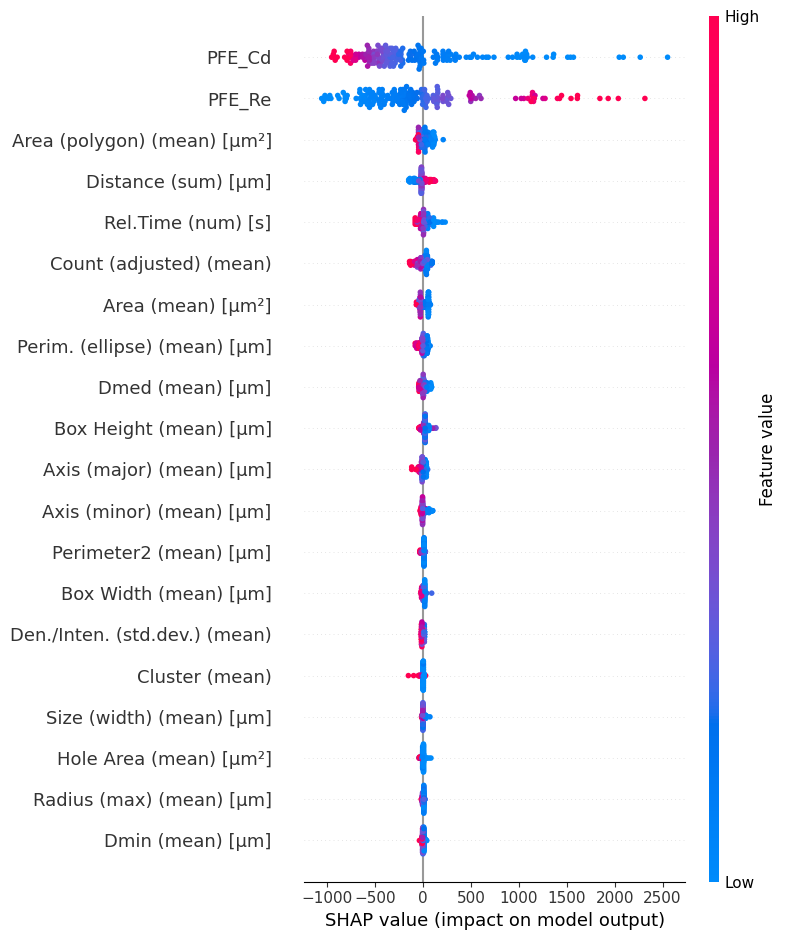

In [39]:
# PFE - GBR
explainer = shap.Explainer(pfe_gbr_model)
shap_values_pfe = explainer(X_test_pfe)

shap.summary_plot(shap_values_pfe, X_test_pfe)


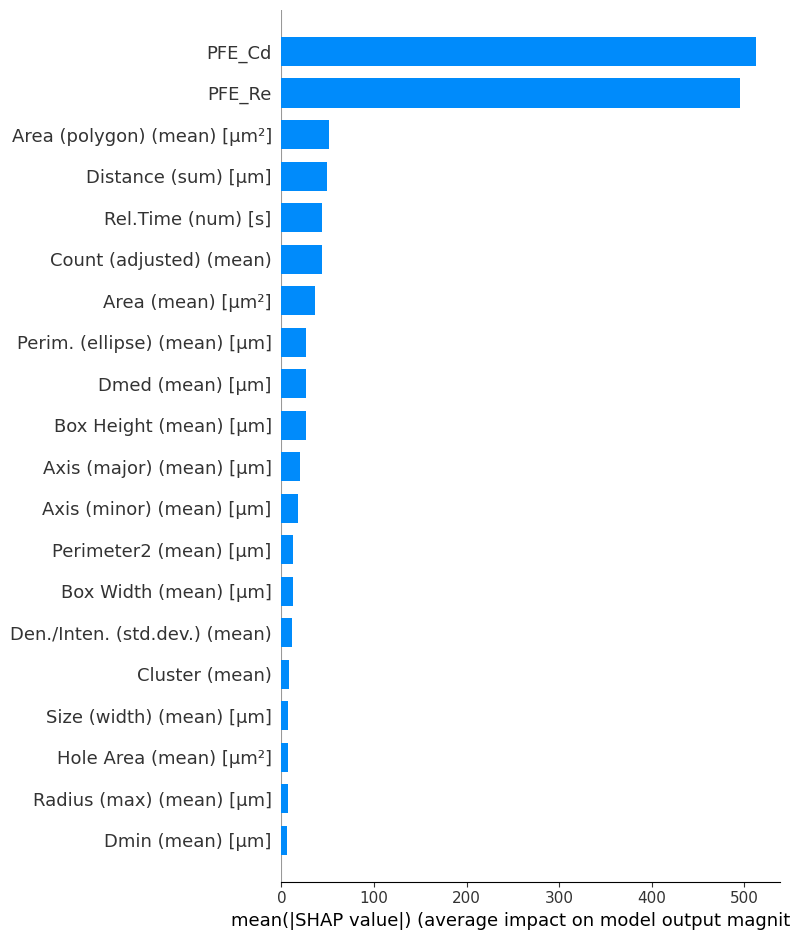

In [40]:
shap.summary_plot(shap_values_pfe, X_test_pfe, plot_type="bar", show=False)
plt.tight_layout()

In [43]:
import pandas as pd
import numpy as np

shap_df = pd.DataFrame(
    shap_values,
    columns=X_test_.columns
)

summary = pd.DataFrame({
    "mean_shap": shap_df.mean(),
    "mean_abs_shap": shap_df.abs().mean()
}).sort_values("mean_abs_shap", ascending=False)


In [44]:

summary.sort_values("mean_abs_shap", ascending = False)


,mean_shap,mean_abs_shap
PFE_Cd,-46.538669,512.813358
PFE_Re,-32.046543,495.228394
Area (polygon) (mean) [µm²],22.464488,51.295995
Distance (sum) [µm],-17.632558,49.494109
Rel.Time (num) [s],15.281464,44.190309
Count (adjusted) (mean),3.260052,44.093220
Area (mean) [µm²],11.804062,36.341790
Perim. (ellipse) (mean) [µm],6.213597,26.946490
Dmed (mean) [µm],7.176091,26.492767
Box Height (mean) [µm],19.228697,26.430115


# 6. Bootstrap analysis


In [45]:
n_boot = 100
rng = np.random.default_rng(42)

In [46]:
y_test_np = np.array(y_test)
y_pred_np = np.array(y_pred_pfe)

In [47]:
mae_boot = []
n = len(y_test_np)

In [48]:
rng.integers(0,2,size =2 )

array([0, 1])

In [49]:
for _ in range(n_boot):

    # * a cada iteração, dentro de um range de 0 a 100, é gerado um array de tamanho igual ao dataset de 
    #   de teste e numeros possiveis iguais aos indices deste dataset. É entao appendado em uma lista os
    #   erros absolutos obtidos com uma amostra do dataset de teste e predicoes, considerando o conjunto
    #   de indices dados por idx 
    idx =  rng.integers(0,n, size = n) 
    mae_boot.append(mean_absolute_error(y_test_np[idx], y_pred_np[idx]))

mae_boot = np.array(mae_boot)

mean_mae = mae_boot.mean()
std_mae = mae_boot.std(ddof=1)
ci_low, ci_high =np.percentile(mae_boot, [2.5, 97.5])

In [50]:
print(f"Bootstrap MAE (n={n_boot})")
print (f"Mean Bootstrap: {mean_mae:.2f} µm/s")
print (f"DP: {std_mae:.2f}µm/s")
print(f"IC 95%: [{ci_low:.2f},{ci_high:.2f}] µm/s")

Bootstrap MAE (n=100)
Mean Bootstrap: 126.13 µm/s
DP: 14.54µm/s
IC 95%: [98.57,158.48] µm/s


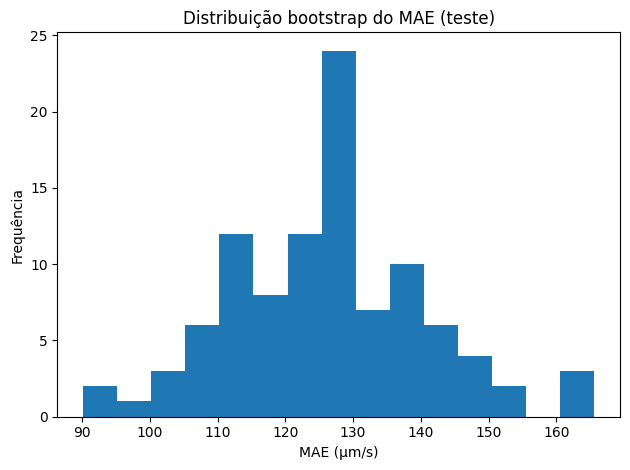

In [51]:
# 6) Histograma
plt.figure()
plt.hist(mae_boot, bins=15)
plt.xlabel("MAE (µm/s)")
plt.ylabel("Frequência")
plt.title("Distribuição bootstrap do MAE (teste)")
plt.tight_layout()
plt.show()

In [52]:
# =========================
# Bootstrap (MAE + IC 95%)
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

import matplotlib.pyplot as plt

# 1) Carregar dados

file_path = './content/dados_jamovi.xlsx'  # Upload your dataset to Colab
df = pd.read_excel(file_path)

target_col = "Velocity (mean) [µm/s]"
if target_col not in df.columns:
    raise ValueError(f"Coluna alvo não encontrada: {target_col}")

# 2) PFE (mesmo do código SHAP)
rho_f = 1000.0
mu = 0.001

A = df["Area (mean) [µm²]"] * 1e-12
r = df["Radius (max) (mean) [µm]"] * 1e-6
v = df[target_col] * 1e-6

d = 2.0 * np.sqrt(A / np.pi)
Re = (rho_f * v * d) / mu


In [53]:
Re = Re.replace([np.inf, -np.inf], np.nan)
Re = Re.where(Re > 0, np.nan)

Cd = 24.0 / Re
Fd = 0.5 * rho_f * Cd * A * (v ** 2)
r2 = r ** 2

df["PFE_Re"] = Re
df["PFE_Cd"] = Cd
df["PFE_Fd"] = Fd
df["PFE_r2"] = r2

# 3) Montar X e y
X = df.drop(columns=[target_col]).select_dtypes(include=[np.number]).copy()
y = df[target_col].copy()


Bootstrap MAE (n=100)
Média: 126.13 µm/s
DP:    14.71 µm/s
IC95%: [99.41, 159.08] µm/s


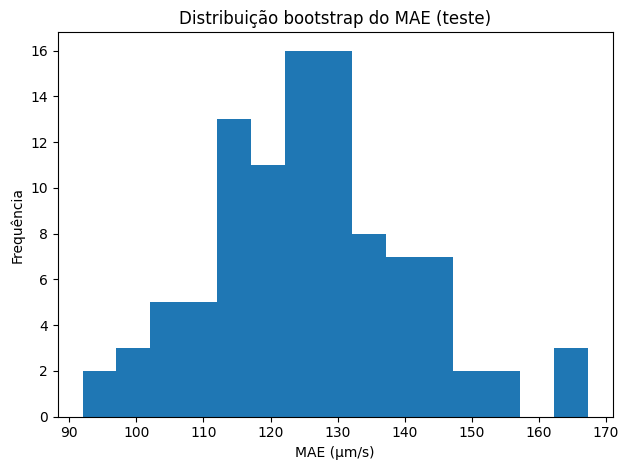

In [54]:

mask = X.notna().all(axis=1) & y.notna()
X = X.loc[mask]
y = y.loc[mask]

# 4) Split e treino
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# 5) Bootstrap no teste (reamostragem dos pares (y_test, y_pred))
n_boot = 100
rng = np.random.default_rng(42)

y_test_np = np.array(y_test)
y_pred_np = np.array(y_pred)

mae_boot = []
n = len(y_test_np)

for _ in range(n_boot):
    idx = rng.integers(0, n, size=n)  # com reposição
    mae_boot.append(mean_absolute_error(y_test_np[idx], y_pred_np[idx]))

mae_boot = np.array(mae_boot)

mean_mae = mae_boot.mean()
std_mae = mae_boot.std(ddof=1)
ci_low, ci_high = np.percentile(mae_boot, [2.5, 97.5])

print(f"Bootstrap MAE (n={n_boot})")
print(f"Média: {mean_mae:.2f} µm/s")
print(f"DP:    {std_mae:.2f} µm/s")
print(f"IC95%: [{ci_low:.2f}, {ci_high:.2f}] µm/s")

# 6) Histograma
plt.figure()
plt.hist(mae_boot, bins=15)
plt.xlabel("MAE (µm/s)")
plt.ylabel("Frequência")
plt.title("Distribuição bootstrap do MAE (teste)")
plt.tight_layout()
plt.show()

# 7. Robustness Analysis - Noise Injection

## 7.1. Performance Degradation Under Noise

# 8. Error Analysis by Morphological Class